In [1]:
from sklearn import svm
import pandas as pd

In [2]:
partitions = [100, 200, 300, 478]
trainpath = '../../../data/top30groups/OneHotLongLatCombined/scaledtrain1'
testpath = '../../../data/top30groups/OneHotLongLatCombined/scaledtest1'

In [3]:
traindatas = []
testdatas = []
for i in range(len(partitions)):
    traindata = pd.read_csv(f'{trainpath}/train{partitions[i]}.csv')
    testdata = pd.read_csv(f'{testpath}/test{partitions[i]}.csv')
    traindatas.append(traindata)
    testdatas.append(testdata)

In [4]:
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
results = {}

X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(partitions)):
    print(f"EVALUATING PARTITION {i+1}")

    X_train = traindatas[i].drop(columns=['gname'])
    X_test = testdatas[i].drop(columns=['gname'])
    y_train = traindatas[i]['gname']
    y_test = testdatas[i]['gname']

    # Encode labels to integers
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

    X_trains.append(X_train)
    X_tests.append(X_test)
    y_trains.append(y_train_encoded)
    y_tests.append(y_test_encoded)

    results[i] = {}
    for kernel in kernels:
        clf = svm.SVC(kernel=kernel)
        clf.fit(X_train, y_train_encoded)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test_encoded, y_pred)
        results[i][kernel] = acc
        print(f"Partition {i+1}, Kernel: {kernel}, Accuracy: {acc:.4f}")
    print('..................................')


EVALUATING PARTITION 1
Partition 1, Kernel: linear, Accuracy: 0.4811
Partition 1, Kernel: rbf, Accuracy: 0.3522
Partition 1, Kernel: sigmoid, Accuracy: 0.2900
Partition 1, Kernel: poly, Accuracy: 0.2500
..................................
EVALUATING PARTITION 2
Partition 2, Kernel: linear, Accuracy: 0.5428
Partition 2, Kernel: rbf, Accuracy: 0.3994
Partition 2, Kernel: sigmoid, Accuracy: 0.2939
Partition 2, Kernel: poly, Accuracy: 0.2856
..................................
EVALUATING PARTITION 3
Partition 3, Kernel: linear, Accuracy: 0.5893
Partition 3, Kernel: rbf, Accuracy: 0.4311
Partition 3, Kernel: sigmoid, Accuracy: 0.2867
Partition 3, Kernel: poly, Accuracy: 0.3144
..................................
EVALUATING PARTITION 4
Partition 4, Kernel: linear, Accuracy: 0.6345
Partition 4, Kernel: rbf, Accuracy: 0.4618
Partition 4, Kernel: sigmoid, Accuracy: 0.2567
Partition 4, Kernel: poly, Accuracy: 0.3683
..................................


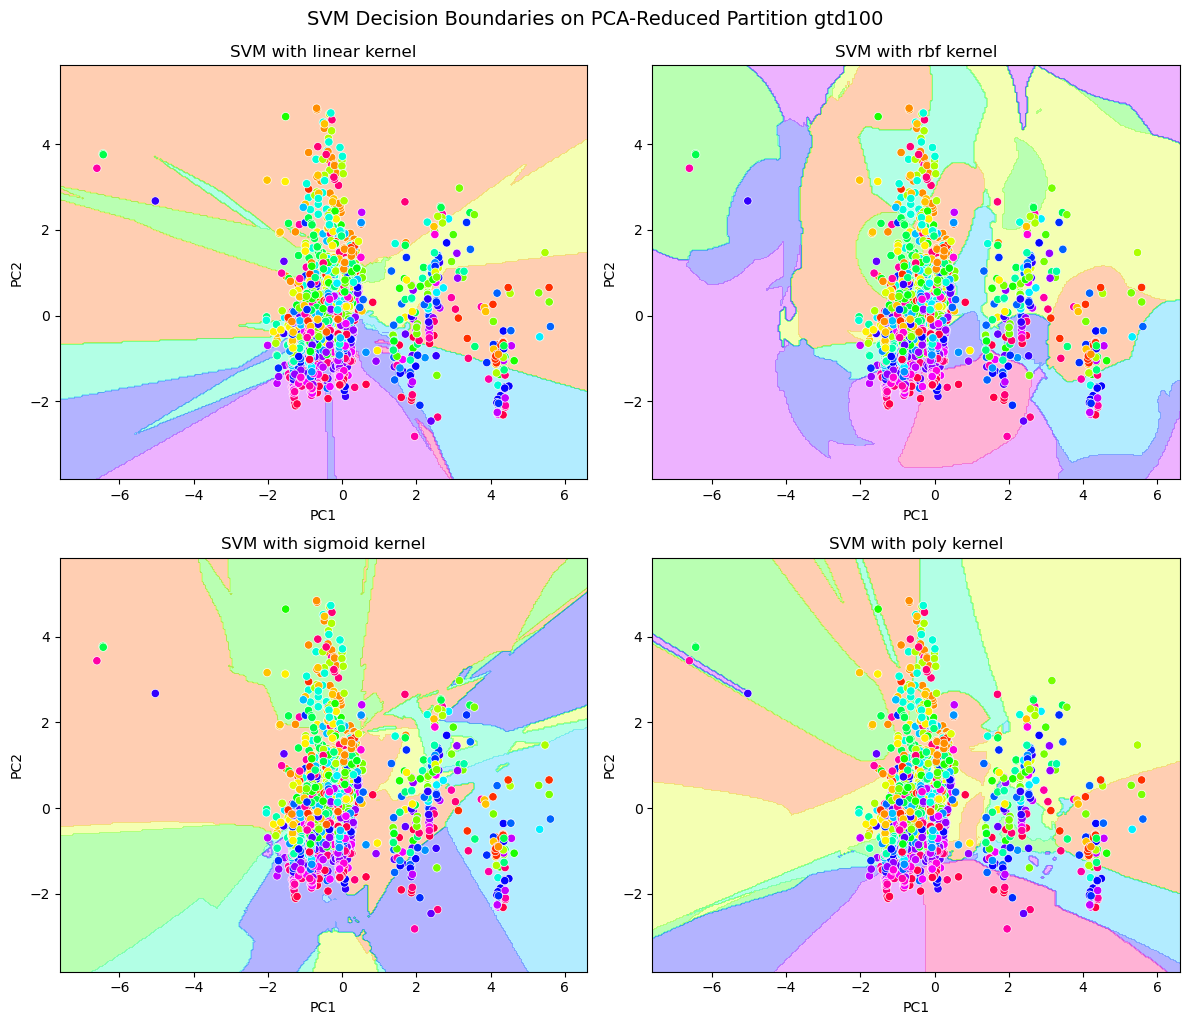

In [5]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap


# Partition
X_orig = X_trains[0]
y = y_trains[0]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_orig)

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Create meshgrid for contour plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

num_classes = len(np.unique(y))
palette = sns.color_palette("hsv", num_classes)
cmap = ListedColormap(palette)

for idx, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel)
    clf.fit(X, y)
    
    # Predict decision function over meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=palette, ax=ax, legend=False)
    ax.set_title(f'SVM with {kernel} kernel')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.suptitle('SVM Decision Boundaries on PCA-Reduced Partition gtd100', fontsize=14, y=1.02)
plt.show()



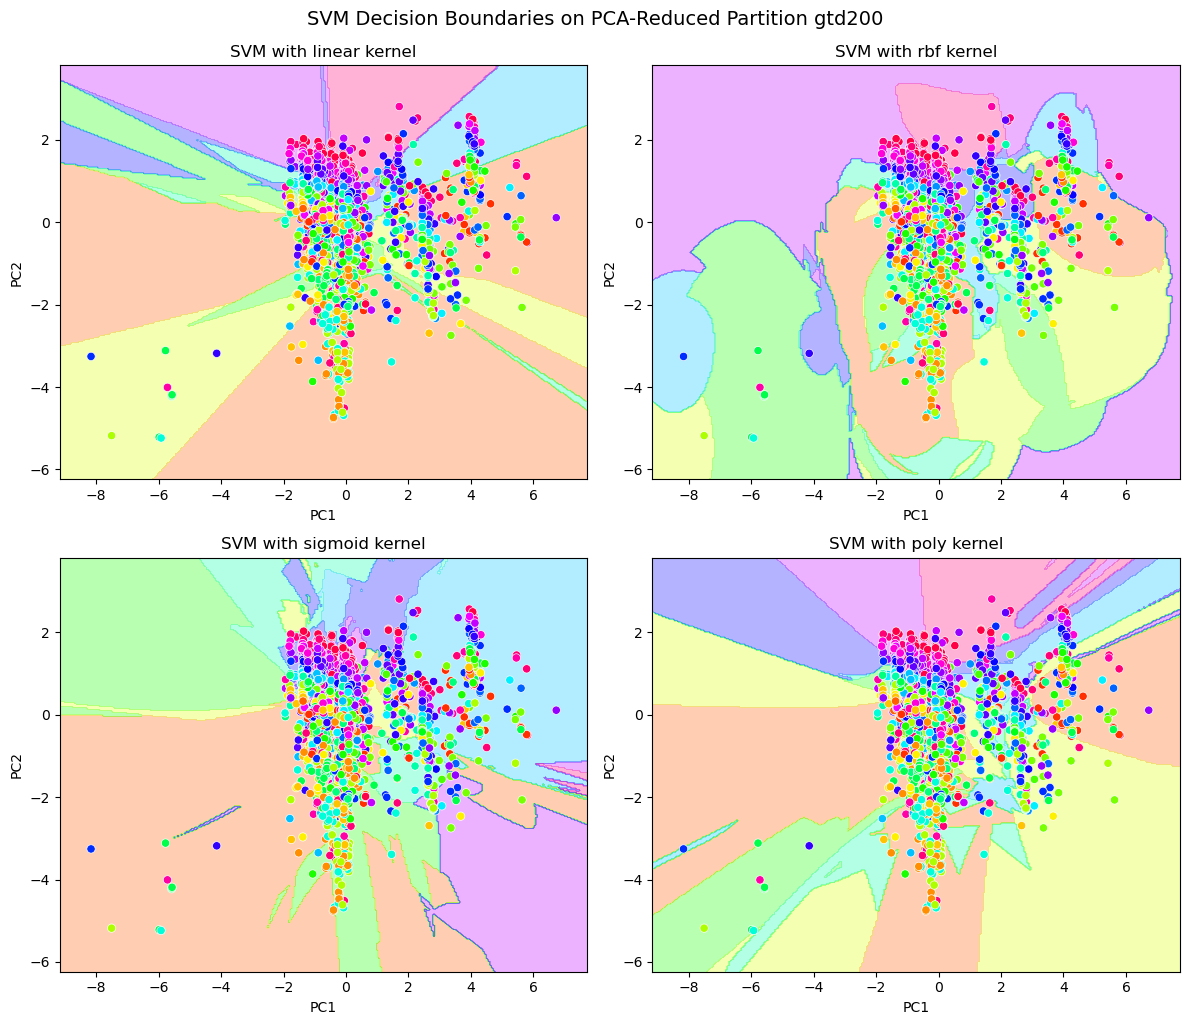

In [6]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap


# Partition
X_orig = X_trains[1]
y = y_trains[1]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_orig)

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Create meshgrid for contour plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

num_classes = len(np.unique(y))
palette = sns.color_palette("hsv", num_classes)
cmap = ListedColormap(palette)


for idx, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel)
    clf.fit(X, y)
    
    # Predict decision function over meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=palette, ax=ax, legend=False)
    ax.set_title(f'SVM with {kernel} kernel')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.suptitle('SVM Decision Boundaries on PCA-Reduced Partition gtd200', fontsize=14, y=1.02)
plt.show()


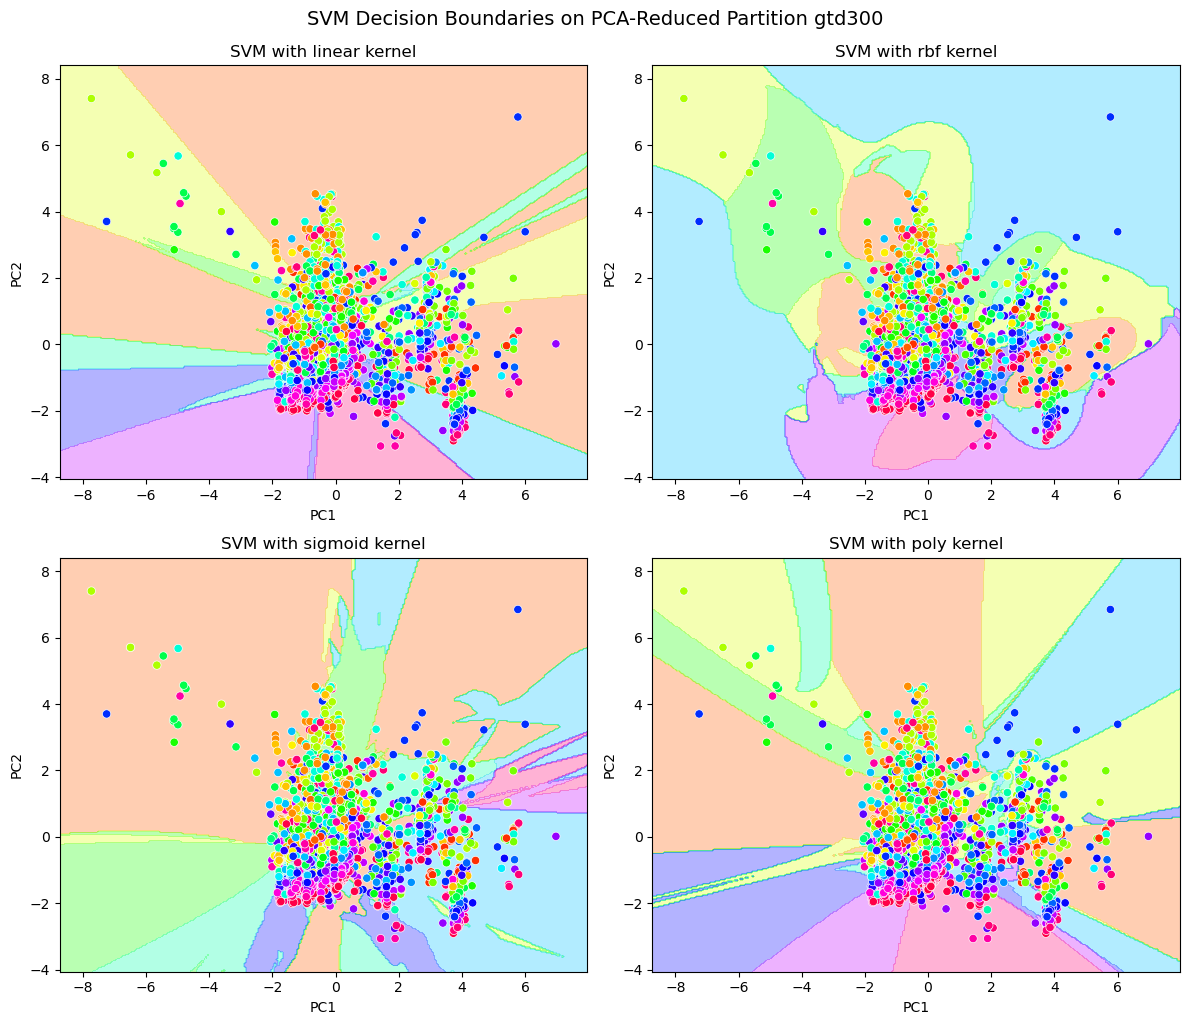

In [7]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Partition
X_orig = X_trains[2]
y = y_trains[2]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_orig)

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Create meshgrid for contour plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

num_classes = len(np.unique(y))
palette = sns.color_palette("hsv", num_classes)
cmap = ListedColormap(palette)


for idx, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel)
    clf.fit(X, y)
    
    # Predict decision function over meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=palette, ax=ax, legend=False)
    ax.set_title(f'SVM with {kernel} kernel')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.suptitle('SVM Decision Boundaries on PCA-Reduced Partition gtd300', fontsize=14, y=1.02)
plt.show()


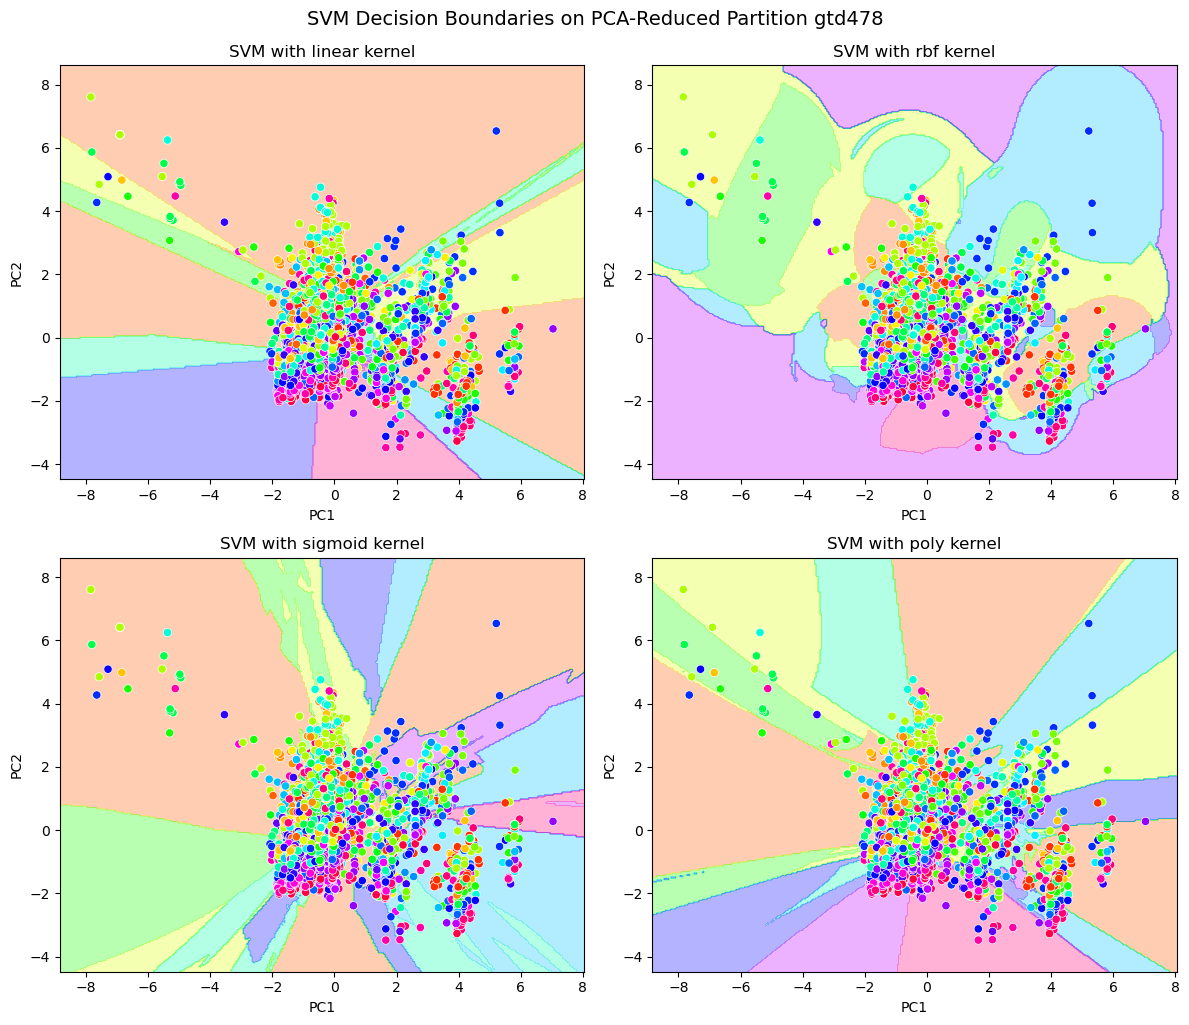

In [8]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Partition
X_orig = X_trains[3]
y = y_trains[3]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_orig)

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Create meshgrid for contour plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

num_classes = len(np.unique(y))
palette = sns.color_palette("hsv", num_classes)
cmap = ListedColormap(palette)


for idx, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel)
    clf.fit(X, y)
    
    # Predict decision function over meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=palette, ax=ax, legend=False)
    ax.set_title(f'SVM with {kernel} kernel')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.suptitle('SVM Decision Boundaries on PCA-Reduced Partition gtd478', fontsize=14, y=1.02)
plt.show()
